### Tuning Pytorch2 Agent Hyperparameters
#### Test Configuration: MEDIUM
#### 10 States, Alphabet Size 2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [4]:
results = pd.read_csv("pytorch_test_10_2.csv")
results.drop(columns='id',inplace=True)
results

,self.eps_decay_steps,self.lr,self.gamma,self.n_hist,sum_smooth_av
0,5000,0.001,0.990,3,5962.988571
1,4500,0.001,0.990,3,6420.017143
2,4000,0.001,0.990,3,5965.702857
3,3500,0.001,0.990,3,6043.525714
4,3000,0.001,0.990,3,6548.920000
...,...,...,...,...,...
61,500,0.001,0.825,12,3963.828571
62,500,0.001,0.800,6,4232.462857
63,500,0.001,0.800,12,4171.257143
64,500,0.001,0.775,6,3882.245714


### Handle Outliers:
1. Remove Outliers (Sum > 10,000)
2. Use Logarithmic Scale of Sum of Smoothed Average

In [5]:
outlier = []
for index, row in results.iterrows():
    if row['sum_smooth_av'] > 10000:
        outlier.append(math.nan)
    else:
        outlier.append(0)
results = pd.concat([results, pd.DataFrame(outlier,columns=['outlier'])], axis=1)

results.dropna(inplace=True)


In [21]:
results['log_sum'] = np.log(results['sum_smooth_av'])
results

,self.eps_decay_steps,self.lr,self.gamma,self.n_hist,sum_smooth_av,outlier,log_sum
0,5000,0.001,0.990,3,5962.988571,0.0,8.693327
1,4500,0.001,0.990,3,6420.017143,0.0,8.767176
2,4000,0.001,0.990,3,5965.702857,0.0,8.693782
3,3500,0.001,0.990,3,6043.525714,0.0,8.706743
4,3000,0.001,0.990,3,6548.920000,0.0,8.787055
...,...,...,...,...,...,...,...
61,500,0.001,0.825,12,3963.828571,0.0,8.284966
62,500,0.001,0.800,6,4232.462857,0.0,8.350539
63,500,0.001,0.800,12,4171.257143,0.0,8.335973
64,500,0.001,0.775,6,3882.245714,0.0,8.264169


### Plot Sum of Smoothed Averages Against self.eps_decay_steps, self.gamma

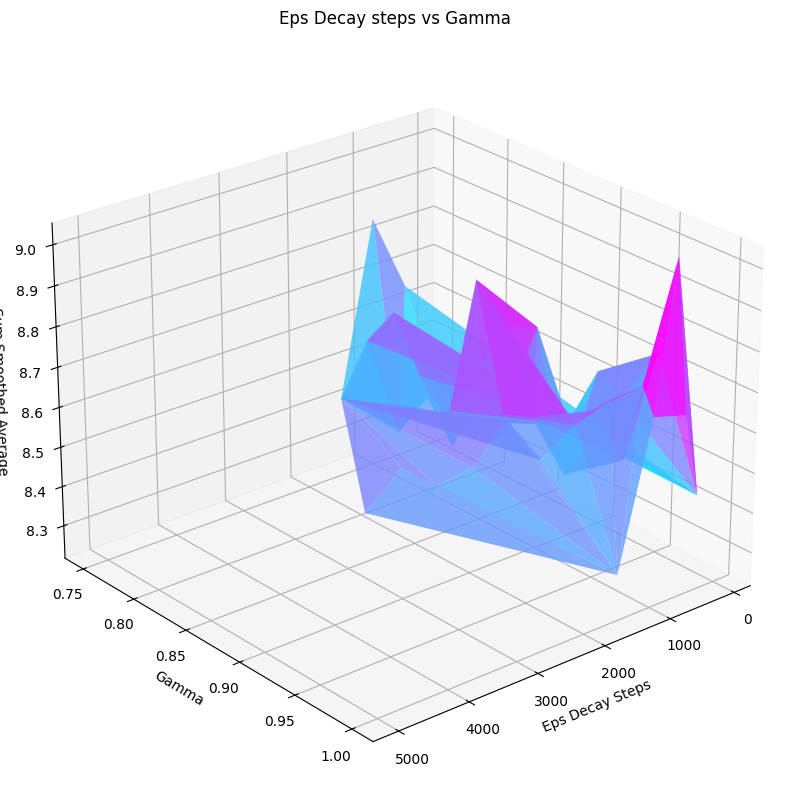

In [43]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(25, 50)

ax.plot_trisurf(results['self.eps_decay_steps'], results['self.gamma'], results['log_sum'], cmap='cool', alpha=0.8)

ax.set_title('Eps Decay steps vs Gamma')
ax.set_xlabel('Eps Decay Steps')
ax.set_ylabel('Gamma')
ax.set_zlabel('Sum Smoothed Average')

plt.show()


### Plot Sum of Smoothed Average Against Eps Decay Steps and n_hist

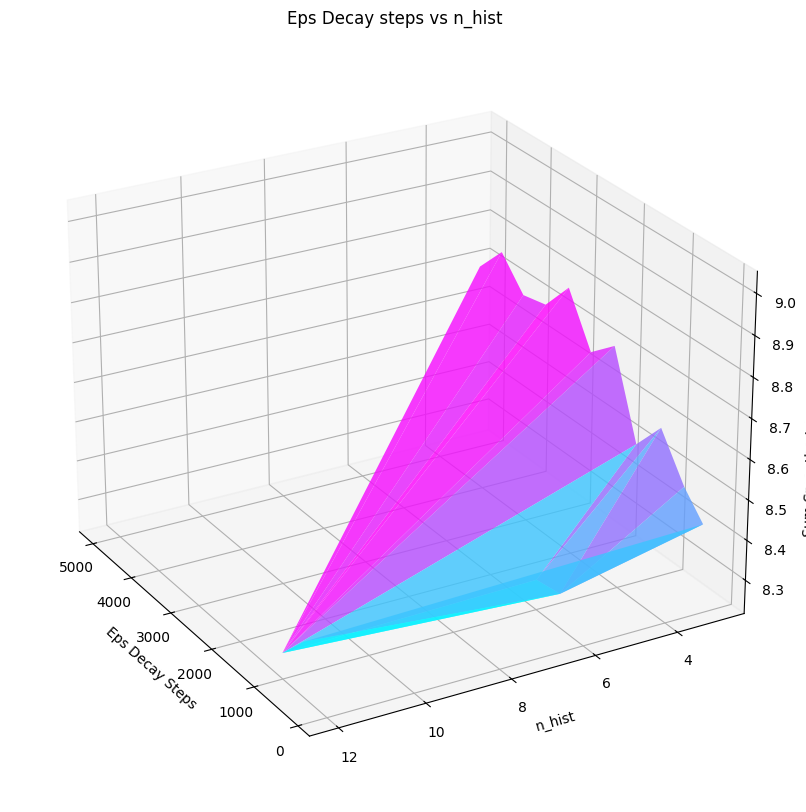

In [7]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(25, 150)

ax.plot_trisurf(results['self.eps_decay_steps'], results['self.n_hist'], results['log_sum'], cmap='cool', alpha=0.8)

ax.set_title('Eps Decay steps vs n_hist')
ax.set_xlabel('Eps Decay Steps')
ax.set_ylabel('n_hist')
ax.set_zlabel('Sum Smoothed Average')

plt.show()


### Plot Sum of Smoothed Average Against Gamma and n_hist

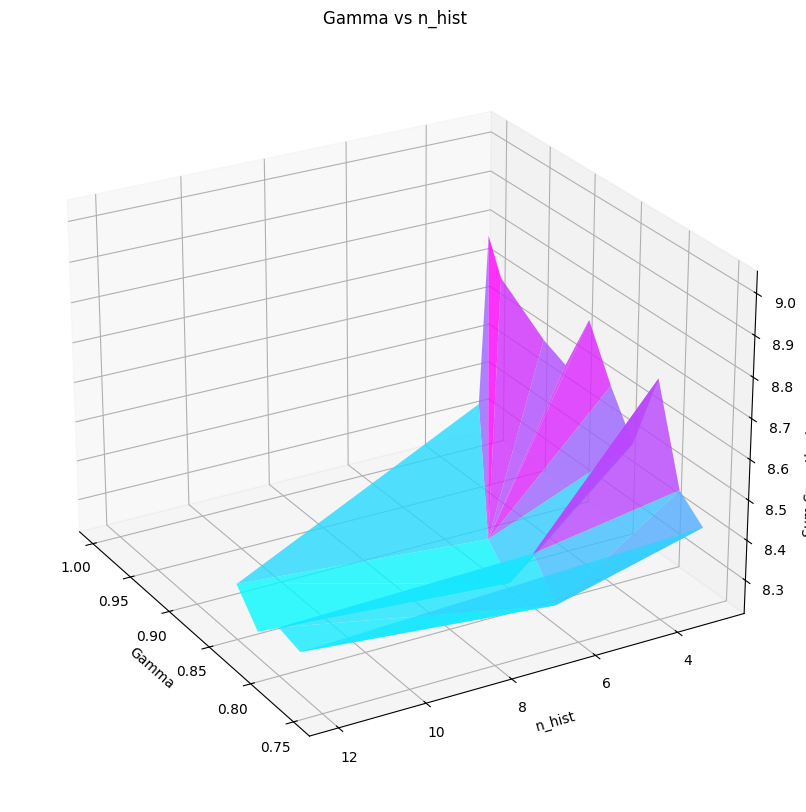

In [8]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(25, 150)

ax.plot_trisurf(results['self.gamma'], results['self.n_hist'], results['log_sum'], cmap='cool', alpha=0.8)

ax.set_title('Gamma vs n_hist')
ax.set_xlabel('Gamma')
ax.set_ylabel('n_hist')
ax.set_zlabel('Sum Smoothed Average')

plt.show()

### Try Graphing Individual Features

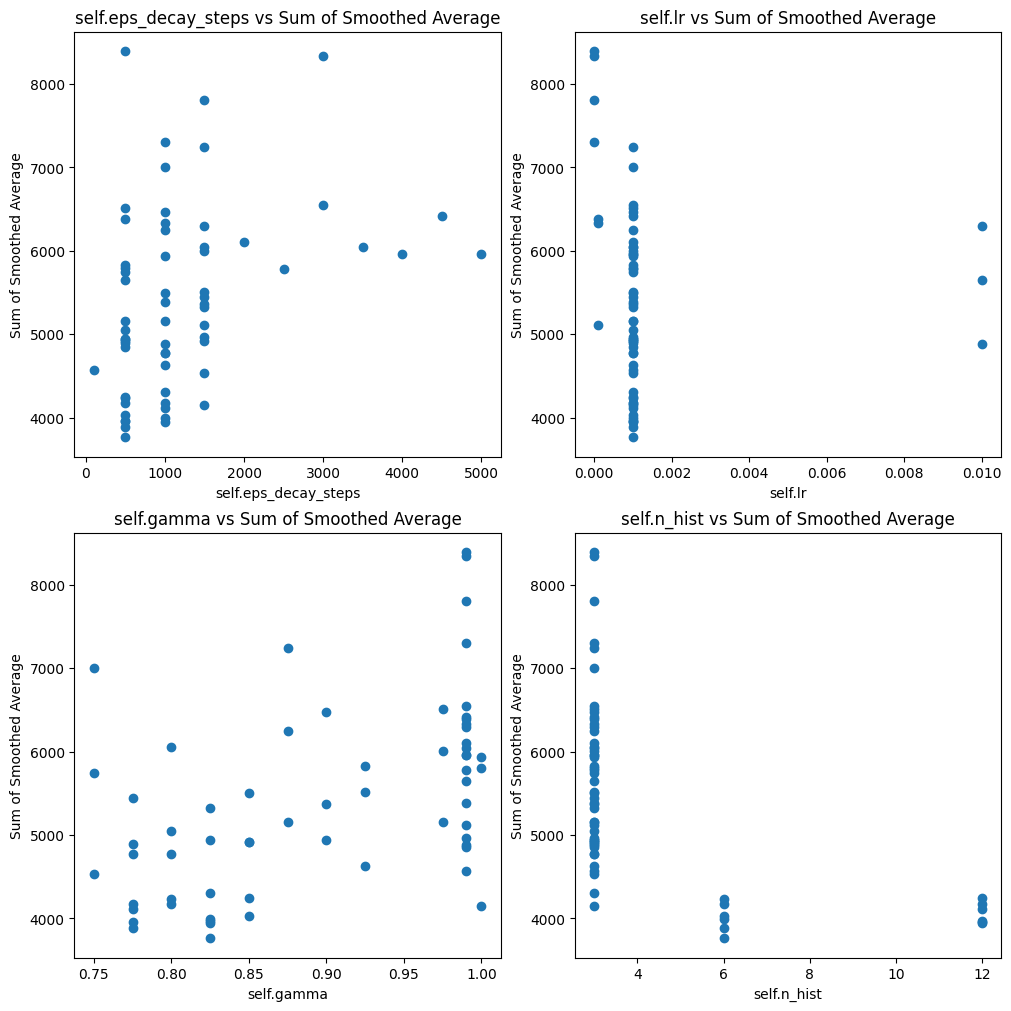

In [15]:
fix, ax = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
features = ['self.eps_decay_steps', 'self.lr', 'self.gamma', 'self.n_hist']


for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        k = 2 * i + j
        #Plot malignant vs benign per feature as a stacked histogram.
        ax[i, j].scatter(results[features[k]], results['sum_smooth_av'])
        ax[i, j].set_title(f'{features[k]} vs Sum of Smoothed Average')
        ax[i, j].set_xlabel(features[k])
        ax[i, j].set_ylabel('Sum of Smoothed Average')

### 3D Scatter

Text(0.5, 0.92, 'Eps Decay Steps v Gamma v N Hist \n (Red = Smoothed Av > 4000, Green = Benign)')

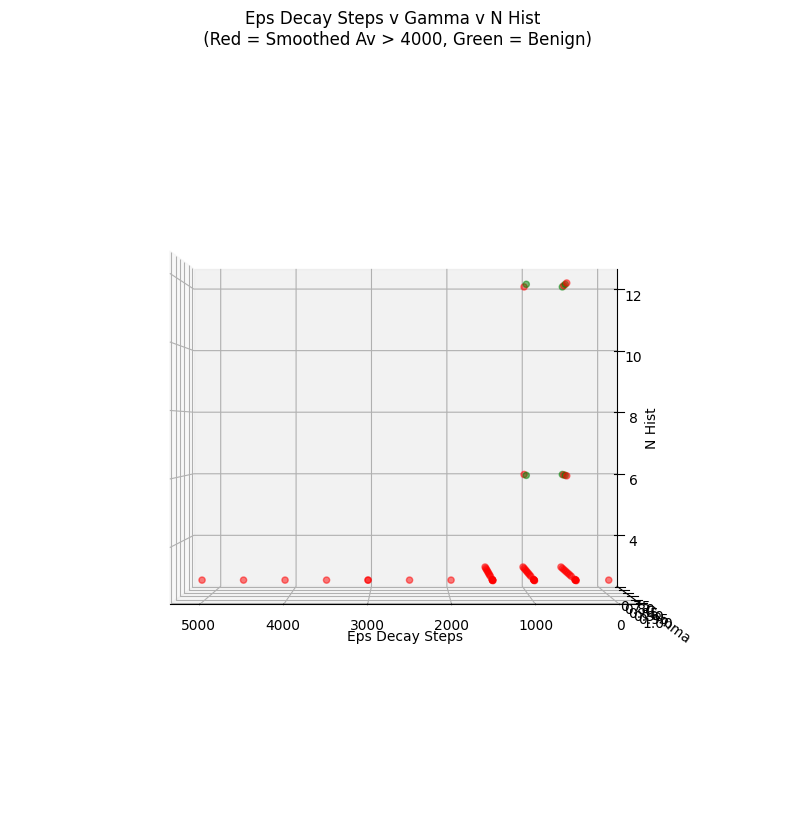

In [28]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(0, 90)

#Color code benign and malignant tumors for contrast.
color = ['red' if x >= 4000 else 'green' for x in results["sum_smooth_av"]]

ax.scatter3D(results['self.eps_decay_steps'],
             results['self.gamma'],
             results['self.n_hist'],
             c=color,
             alpha=0.5)
#My y-axis label kept getting cut off, set zoom to 0.9 to bring it back.
ax.set_box_aspect(None, zoom=0.90)

ax.set_xlabel("Eps Decay Steps")
ax.set_ylabel("Gamma")
ax.set_zlabel("N Hist")
ax.set_title("Eps Decay Steps v Gamma v N Hist \n (Red = Smoothed Av > 4000, Green = Benign)")


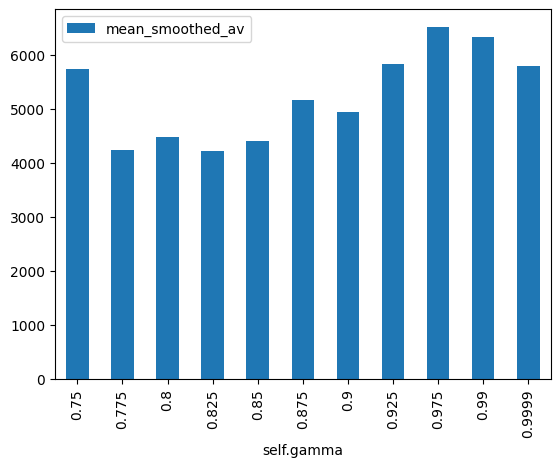

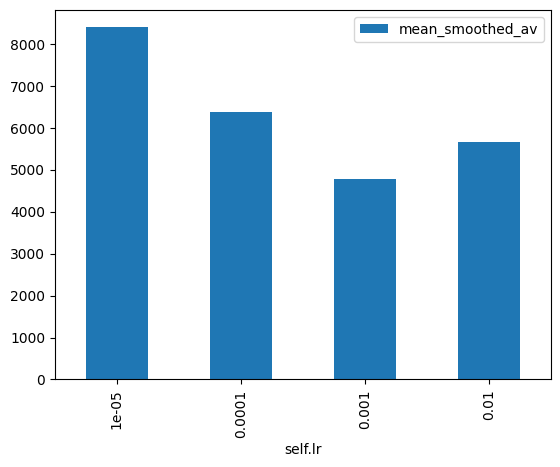

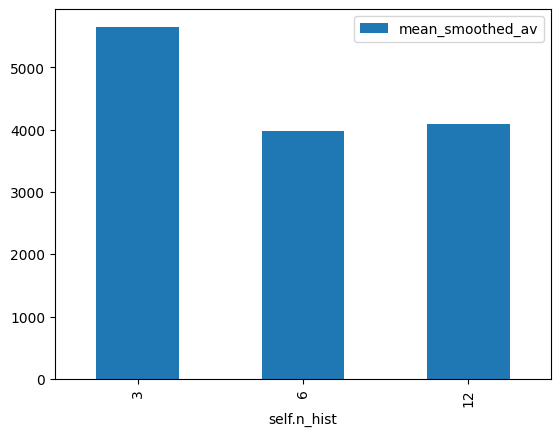

In [59]:
# Group by self eps decay steps = 500, we want to isolate these entries
eps_decay_500 = results[results['self.eps_decay_steps'] == 500]

gamma = eps_decay_500.groupby('self.gamma').agg(mean_smoothed_av=('sum_smooth_av', 'mean'))

lr = eps_decay_500.groupby('self.lr').agg(mean_smoothed_av=('sum_smooth_av', 'mean'))

n_hist = eps_decay_500.groupby('self.n_hist').agg(mean_smoothed_av=('sum_smooth_av', 'mean'))

gamma.plot(kind='bar', use_index=True)
lr.plot(kind='bar', use_index=True)
n_hist.plot(kind='bar', use_index=True)
plt.show()

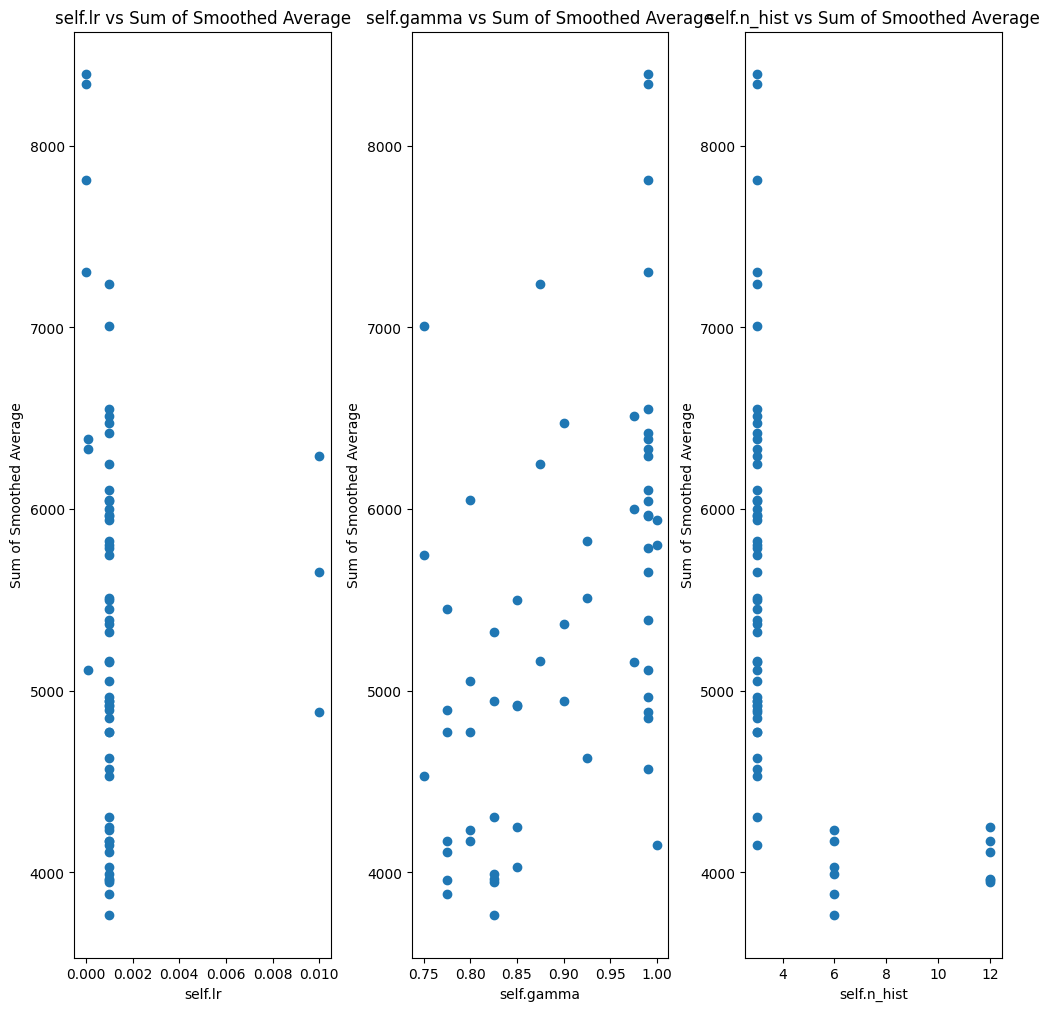

In [43]:
fix, ax = plt.subplots(1, 3, figsize=(10, 10), constrained_layout=True)
features = ['self.lr', 'self.gamma', 'self.n_hist']

for i in range(ax.shape[0]):
        #Plot malignant vs benign per feature as a stacked histogram.
        ax[i].scatter(results[features[i]], results['sum_smooth_av'])
        ax[i].set_title(f'{features[i]} vs Sum of Smoothed Average')
        ax[i].set_xlabel(features[i])
        ax[i].set_ylabel('Sum of Smoothed Average')